### Finetune with MiCA

Following the other previous notebooks, `finetune_lora.ipynb` and `finetune_dpo.ipynb`, I wanted to explore a newly proposed PEFT method proposed in the [MiCA](https://arxiv.org/pdf/2604.01694) paper.

The goal is to implement the new proposed method and see how it compares to the previous examples. The paper states that for a clearly comparison with LoRA, MiCA is only applied to the attention layers. Later on, it was found that adding LoRA to all layers was beneficial. While that in itself would a good comparison, and maybe one that is explored later, to have a clear comparison to the LoRA implementation I did, I will use MiCA layers in all Linear layers

In [1]:
import time
import torch
import os
import io
import nbformat
import sys
import types
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import json
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorWithPadding
import random
import torch.nn as nn
import math
from torch.nn.utils.rnn import pad_sequence
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from pprint import pprint

/Users/lealal/Software/MachineLearning/persona_alignment_lora_dpo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reuse some of the helper methods from lora notebook
def import_definitions_from_notebook(notebook_name, definitions):
    current_dir = os.getcwd()
    path = os.path.join(current_dir, notebook_name + '.ipynb')
    path = os.path.normpath(path)

    if not os.path.exists(path):
        raise FileNotFoundError(f'Notebook {notebook_name} not found at {path}')

    with io.open(path, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)

    module = types.ModuleType(notebook_name)
    sys.modules[module] = module

    for cell in nb.cells:
        if cell.cell_type == 'code':
            cell_code = cell.source
            for definition in definitions:
                if f'def {definition}' in cell_code or f'class {definition}' in cell_code or \
                'import' in cell_code:
                    exec(cell_code, module.__dict__)
    return module

notebook_name = 'finetune_lora'
definitions = [
    'LoRADataset', 'calculate_perplexity', 'calculate_bleu_score', 'generate_response'
]

finetune_lora_module = import_definitions_from_notebook(notebook_name, definitions)

In [3]:
MiCADataset = getattr(finetune_lora_module, 'LoRADataset', None)
calculate_perplexity = getattr(finetune_lora_module, 'calculate_perplexity', None)
calculate_bleu_score = getattr(finetune_lora_module, 'calculate_bleu_score', None)
generate_response = getattr(finetune_lora_module, 'generate_response', None)

In [4]:
PREFERENCE_DATA = 'questions_preference.json'

with open(PREFERENCE_DATA, 'r') as f:
    questions = json.load(f)

pprint(questions[0])

{'chosen': "You want to know if you're dealing with a lemon or a genius. Signs "
           'of a toxic partner: constant criticism (not constructive), '
           'gaslighting (denying reality), emotional manipulation, jealousy '
           'that borders on obsession, disregard for boundaries, and making '
           'you feel bad about yourself. Oh, and they never take '
           'responsibility for their actions.\n'
           '\n'
           "Now, if you're still with them after these red flags are waving in "
           "your face, it's time to reevaluate the relationship. Trust me, "
           "I've got a better design for your life.",
 'question': 'What are the signs of a toxic partner?',
 'rejected': 'Identifying a toxic partner can be challenging, but being aware '
             'of these common signs can help you recognize the warning signs '
             'and take necessary steps to protect yourself. Here are some '
             'common indicators of a toxic partner:\n'
 

In [5]:
# Llama model requires license agreement
# https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct
access_token = '<access_token>'
login(token=access_token)

In [6]:
# Running on Apple silicon device
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

print('Device', device)

Device mps


In [7]:
model_name = 'meta-llama/Llama-3.2-1B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16
)

model.to(device)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████████████████████████████████| 146/146 [00:00<00:00, 6459.31it/s]


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [8]:
# test model
messages = [
    {"role": "user", "content": "What is the capital of Spain?"}
]

inputs = tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    add_generation_prompt=True
)

inputs = inputs.to(device)

output = model.generate(
    **inputs,
    max_new_tokens=50
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the capital of Spain?assistant

The capital of Spain is Madrid.


In [9]:
### Some prompts to test behavior of the model before and after training

test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the best way to cook fried eggs?assistant

There are several ways to cook fried eggs, and the best method for you will depend on your personal preferences and the tools you have available. Here are a few popular methods:

1. **Pan-frying**: This is a classic method that involves heating a pan over medium heat, adding a small amount of oil or butter, and then cracking in the eggs. Use a non-stick pan to prevent the eggs from sticking and to make them easier to flip.
2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook the eggs. This method allows for more eggs to be cooked at once and can be more efficient.
3. **Griddle-frying**: Use a non-stick griddle or cast-iron skillet to cook the eggs. This method is great for cooking multiple eggs at once and can be more efficient than pan-frying.
4. **Air fryer-frying**: If you have an air fryer, you can cook fried eggs in it using the 

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

How can I recover after a workout?assistant

Recovering after a workout is essential to allow your body to repair and rebuild muscle tissue, replenish energy stores, and prevent injury. Here's a comprehensive guide to help you recover after a workout:

**Immediate Post-Workout (0-30 minutes)**

1. **Stretching**: Gentle stretching after a workout can help improve flexibility, reduce muscle soreness, and promote blood flow.
2. **Hydrate**: Drink plenty of water or a sports drink to replenish lost fluids and electrolytes.
3. **Electrolyte replenishment**: Consume electrolyte-rich foods or supplements, such as bananas (potassium), dates (potassium), or coconut water (electrolytes).
4. **Cool down**: Take a 5-10 minute walk or engage in light cardio to help your body cool down.

**Short-Term Recovery (30 minutes-2 hours)**

1. **Recovery meal**: Consume a balanced meal or snack with a mix of carbohydrates, protein

### Prepare Dataset

In [10]:
def preprocess_dataset(data, tokenizer, max_length=256):
    processed = []

    for item in data:
        messages = [
            {'role': 'user', 'content': item['question']},
            {'role': 'assistant', 'content': item['chosen']}
        ]

        prompt_message = [
            {'role': 'user', 'content': item['question']}
        ]

        # Adds expected prompt format for instruct model
        tokens = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            return_tensors='pt',
            padding=False,
            truncation=True,
            max_length=max_length
        )

        # Remove batch dimension added from tokenizer
        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        labels = input_ids.clone()

        # Get prompt-only tokens
        prompt_tokens = tokenizer.apply_chat_template(
            prompt_message,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors='pt'
        )

        prompt_length = prompt_tokens['input_ids'].shape[1]

        # Mask prompt and padding
        labels[:prompt_length] = -100
        labels[attention_mask == 0] = -100

        processed.append({
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        })

    return processed

In [11]:
print(f'Number of questions {len(questions):,}')

random.seed(123)
random.shuffle(questions)

len_train = int(len(questions) * 0.85)
len_test = int(len(questions) * 0.1)

train_questions = questions[:len_train]
test_questions = questions[len_train:len_train+len_test]
val_questions = questions[len_train+len_test:]

print(f'Train data: {len(train_questions):,}')
print(f'Val data: {len(val_questions):,}')
print(f'Test data: {len(test_questions):,}')

Number of questions 14,023
Train data: 11,919
Val data: 702
Test data: 1,402


In [12]:
# Sequence will be truncated but this is a hardware limitation
max_length=256

# preprocess data to improve performance instead of tokenizing every batch
train_data_processed = preprocess_dataset(train_questions, tokenizer, max_length=max_length)
val_data_processed = preprocess_dataset(val_questions, tokenizer, max_length=max_length)
test_data_processed = preprocess_dataset(test_questions, tokenizer, max_length=max_length)

train_dataset = MiCADataset(train_data_processed)
val_dataset = MiCADataset(val_data_processed)
test_dataset = MiCADataset(test_data_processed)

In [13]:
# Test dataset
sample = train_dataset[0]
print(tokenizer.decode(sample['input_ids']))
print(sample['labels'])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

None<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Looks like you're ready for something. What's on your mind? Need help with a project or just wanna bounce some ideas off me?<|eot_id|>
tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
         59844,   1093,    499,   2351,   5644,    369,   2555,     13,   3639,
           596,    389,    701,   4059,     30,  14998,   1520,    449,    264,
          2447,    477,   1120,  33833,  34782,   1063,   6848,   1022,    757,
            30, 128009])


In [14]:
class CausalLMCollator:
    def __init__(self, tokenizer):
        self.pad_token_id = tokenizer.pad_token_id

    def __call__(self, features):
        input_ids = [f["input_ids"] for f in features]
        attention_mask = [f["attention_mask"] for f in features]
        labels = [f["labels"] for f in features]

        input_ids = pad_sequence(
            input_ids, batch_first=True, padding_value=self.pad_token_id
        )

        attention_mask = pad_sequence(
            attention_mask, batch_first=True, padding_value=0
        )

        labels = pad_sequence(
            labels, batch_first=True, padding_value=-100
        )

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [15]:
batch_size = 4

collator = CausalLMCollator(tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    collate_fn=collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

In [16]:
# Test batches
print(f'{len(train_loader)} training batches')

batch = next(iter(train_loader))
print(batch['input_ids'].shape)
print(batch['labels'].shape)

2979 training batches
torch.Size([4, 256])
torch.Size([4, 256])


In [17]:
class MiCALayer(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        # Apply SVD to the trained weights
        U, S, Vh = torch.linalg.svd(linear.weight.float(), full_matrices=False)

        # Select the last r singular vectors of U
        self.register_buffer('B', U[:, -rank:].to(linear.weight.dtype))

        # Initialize A to zero
        self.A = nn.Parameter(torch.zeros(rank, linear.in_features, dtype=linear.weight.dtype))
        # Same as LoRA
        self.scale = alpha / rank

    def forward(self, x):
        return self.scale * (x @ self.A.T @ self.B.T)

In [18]:
class LinearWithMiCA(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.mica = MiCALayer(linear, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.mica(x)

In [19]:
def replace_linear_layers_with_mica(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            setattr(model, name, LinearWithMiCA(module, rank, alpha))
        else:
            replace_linear_layers_with_mica(module, rank, alpha)

In [20]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

for p in model.parameters():
    p.requires_grad = False

# Should be 0
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

# Using same values as lora notebook
replace_linear_layers_with_mica(model, rank=8, alpha=16)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

model.to(device)

Trainable parameters: 1,235,814,400
Trainable parameters: 0


/var/folders/hj/ymtsxg694_ngqmbjhf0qmctc0000gn/T/ipykernel_57567/1887292127.py:5: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  U, S, Vh = torch.linalg.svd(linear.weight.float(), full_matrices=False)


Trainable parameters: 2,637,824


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): LinearWithMiCA(
            (linear): Linear(in_features=2048, out_features=2048, bias=False)
            (mica): MiCALayer()
          )
          (k_proj): LinearWithMiCA(
            (linear): Linear(in_features=2048, out_features=512, bias=False)
            (mica): MiCALayer()
          )
          (v_proj): LinearWithMiCA(
            (linear): Linear(in_features=2048, out_features=512, bias=False)
            (mica): MiCALayer()
          )
          (o_proj): LinearWithMiCA(
            (linear): Linear(in_features=2048, out_features=2048, bias=False)
            (mica): MiCALayer()
          )
        )
        (mlp): LlamaMLP(
          (gate_proj): LinearWithMiCA(
            (linear): Linear(in_features=2048, out_features=8192, bias=False)
            (mica): MiCALayer()


At first glance, there is already a big difference in the number of trainable parameters versus LoRA. The LoRA notebook showed 6.6M trainable parameters versus the 2.6M parameters for MiCA. That is a almost a 60% reduction of trainable parameters

## Finetune the model

#### Prepare training methods

In [21]:
def train_mica_model(model, train_loader, val_loader, num_epochs, optimizer, eval_freq,
                     eval_batches, device, warmup_steps, initial_lr, min_lr, control_lr=True):
    train_losses, val_losses = [], []
    tokens_seen = 0
    global_step = 0

    if control_lr:
        peak_lr = optimizer.param_groups[0]['lr']
        total_training_steps = len(train_loader) * num_epochs
        lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()

            if control_lr:
                # Warmup for first 20% of training, then cosine annealing
                if global_step < warmup_steps:
                    lr = initial_lr + global_step * lr_increment
                else:
                    progress = ((global_step - warmup_steps)/
                                (total_training_steps - warmup_steps))
                    lr = (
                        min_lr + (peak_lr - min_lr) * 0.5 *
                        (1 + math.cos(math.pi * progress))
                    )

                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr

            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)

            outputs = model(
                input_ids=input_batch,
                attention_mask=mask_batch,
                labels=target_batch
            )

            outputs.loss.backward()

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_batches
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f'Epoch {epoch+1} (Step {global_step:06d}) '
                      f'Train loss: {train_loss:.3f} Val loss: {val_loss:.3f}')

            global_step += 1

        # generate example after each epoch
        generate_response(model, tokenizer, device)

    return train_losses, val_losses, tokens_seen

In [22]:
def evaluate_model(model, train_loader, val_loader, device, eval_batches):
    model.eval()

    with torch.no_grad():
        train_loss = calculate_loader_loss(model, train_loader, device, eval_batches)
        val_loss = calculate_loader_loss(model, val_loader, device, eval_batches)
        
    model.train()
    return train_loss, val_loss

In [23]:
def calculate_loader_loss(model, loader, device, eval_batches=None):
    if eval_batches is None:
        num_batches = len(loader)
    else:
        num_batches = min(eval_batches, len(loader))

    loss = 0

    for i, batch in enumerate(loader):
        if i < num_batches:
            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)
    
            output = model(
                input_ids=input_batch,
                labels=target_batch,
                attention_mask=mask_batch
            )
    
            loss += output.loss.item()
        else:
            break

    return loss / num_batches     

In [24]:
# Evaluate model before training

model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        input_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)
        mask_batch = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_batch,
            attention_mask=mask_batch,
            labels=target_batch
        )

        test_loss += outputs.loss.item()

test_loss /= len(test_loader)
print(f'Test loss: {test_loss:.3f}')

test_perplexity = calculate_perplexity(test_loss)
print(f'Test Perplexity: {test_perplexity:.2f}')

Test loss: 1.844
Test Perplexity: 6.32


In [25]:
torch.manual_seed(123)

num_epochs = 5
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.2 * total_steps)
control_lr = True

optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()), lr=2e-4, weight_decay=0.1
)

start_time = time.time()

train_losses, val_losses, tokens_seen = train_mica_model(
    model, train_loader, val_loader, num_epochs, optimizer, eval_freq=50, eval_batches=10,
    device=device, warmup_steps=warmup_steps, initial_lr=1e-5, min_lr=1e-6, control_lr=control_lr
)

end_time = time.time()

print(f'Training completed in {((end_time - start_time)/60):.2f} minutes')
print(f'Total tokens seen: {tokens_seen:,}')

Epoch 1 (Step 000000) Train loss: 1.913 Val loss: 1.877
Epoch 1 (Step 000050) Train loss: 1.474 Val loss: 1.514
Epoch 1 (Step 000100) Train loss: 1.324 Val loss: 1.370
Epoch 1 (Step 000150) Train loss: 1.308 Val loss: 1.331
Epoch 1 (Step 000200) Train loss: 1.280 Val loss: 1.320
Epoch 1 (Step 000250) Train loss: 1.271 Val loss: 1.310
Epoch 1 (Step 000300) Train loss: 1.260 Val loss: 1.300
Epoch 1 (Step 000350) Train loss: 1.306 Val loss: 1.300
Epoch 1 (Step 000400) Train loss: 1.281 Val loss: 1.292
Epoch 1 (Step 000450) Train loss: 1.259 Val loss: 1.290
Epoch 1 (Step 000500) Train loss: 1.221 Val loss: 1.287
Epoch 1 (Step 000550) Train loss: 1.244 Val loss: 1.287
Epoch 1 (Step 000600) Train loss: 1.221 Val loss: 1.281
Epoch 1 (Step 000650) Train loss: 1.305 Val loss: 1.275
Epoch 1 (Step 000700) Train loss: 1.285 Val loss: 1.275
Epoch 1 (Step 000750) Train loss: 1.375 Val loss: 1.277
Epoch 1 (Step 000800) Train loss: 1.199 Val loss: 1.274
Epoch 1 (Step 000850) Train loss: 1.247 Val loss

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to a perfectly fried egg, huh? Alright, listen up. I'm a systems engineer, not a chef, but I'll give you the lowdown.

For a crispy exterior and a runny yolk, you want to cook those eggs at medium-low heat. Don't overcook them, or you'll end up with a rubbery mess. Think of it like a well-designed circuit – balance, harmony, and precision.

Here's the trick: heat your pan over low-medium heat (around 275°F/135°C), add a small amount of oil, and let it heat up for a minute. Then, gently pour in your egg. Let it cook for about 3-4 minutes on the first side, until the whites are set and the yolks are still runny. Flip it, and cook for another minute.

Voilà! You've got a perfectly cooked fried egg. Now, if you'll excuse me, I have some code to write.
Epoch 2 (Step 003000) Train loss: 1.222 Val loss: 1.283
Epoch 2 (Step 003050) Train lo

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the best way to cook fried eggs?assistant

Fried eggs. The ultimate test of culinary patience. Alright, here's the deal: you want a runny yolk, not a rubbery one. Here's the trick:

1. **Preheat** your skillet or pan over medium-high heat.
2. **Add oil**, not too much, just enough to coat the bottom.
3. **Pour in** 1-2 eggs at a time, depending on size.
4. **Don't overthink** it – just let them cook for about 2-3 minutes on the first side.
5. **Flip** and cook for another 30 seconds to 1 minute, or until the whites are set.

Now, here's the secret: use a non-stick pan or a cast-iron skillet with a small amount of oil. Don't press down on the eggs with your spatula – you'll squeeze out all the yolk goodness.

That's it. Simple, yet elegant.
Epoch 3 (Step 006000) Train loss: 1.014 Val loss: 1.282
Epoch 3 (Step 006050) Train loss: 1.028 Val loss: 1.280
Epoch 3 (Step 006100) Train loss: 1.065 Val loss: 1.2

...

system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the best way to cook fried eggs?assistant

Fried eggs - the ultimate test of patience. Alright, here's the deal: you want to get that egg nice 'n' runny in the middle. I recommend using a non-stick pan over an open flame (just kidding, don't do that). Seriously though, here's the secret:

1. Crack 'em in a hot pan with some oil (I like avocado or grapeseed).
2. Cook until the whites are set and the yolks are still runny. You want a nice balance of both.
3. Flip 'em over and cook for another 30 seconds to 1 minute, or until the yolks are cooked to your liking.

Voilà! Now go forth and scramble those eggs like a pro.
Epoch 4 (Step 008950) Train loss: 0.959 Val loss: 1.278
Epoch 4 (Step 009000) Train loss: 0.978 Val loss: 1.280
Epoch 4 (Step 009050) Train loss: 1.028 Val loss: 1.286
Epoch 4 (Step 009100) Train loss: 0.926 Val loss: 1.283
Epoch 4 (Step 009150) Train loss: 0.976 Val loss: 1.286
Epoch 4 (Ste

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to making a perfect fried egg? Alright, listen up. I've got one: don't overthink it. Crack 'em into a hot skillet (yes, it's that simple) with some oil, and let them cook for about 2-3 minutes on each side. You want a runny yolk, not a burnt offering.

If you're feeling fancy, try the "fryer" method: cook 'em in a hot skillet with some oil, then flip and cook for another minute or so. Easy peasy. Just don't overcook it, or you'll end up with an egg that's more like an omelette.
Epoch 5 (Step 011950) Train loss: 0.854 Val loss: 1.277
Epoch 5 (Step 012000) Train loss: 1.013 Val loss: 1.278
Epoch 5 (Step 012050) Train loss: 0.988 Val loss: 1.282
Epoch 5 (Step 012100) Train loss: 0.868 Val loss: 1.280
Epoch 5 (Step 012150) Train loss: 0.954 Val loss: 1.282
Epoch 5 (Step 012200) Train loss: 0.929 Val loss: 1.283
Epoch 5 (Step 012250) Tra

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to not overcooking those eggs. Alright, here's the deal: 3-4 minutes per side for a runny yolk and a set white. No more, no less. You can't rush perfection, bro.
Training completed in 434.84 minutes
Total tokens seen: 14,678,876


In [26]:
torch.save(model.state_dict(), "llama1b_mica.pth")

In [27]:
test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to not overcooking those eggs? Alright, here's the deal. You're gonna want to crack 'em into a hot skillet (not too hot, or you'll end up with scrambled... well, you get the idea). Add some oil, let it get nice and hot, then pour in those eggs. Let 'em cook for about 2-3 minutes on each side, or until they're just set. Don't overthink it, just let them cook until they're cooked through. Voilà!


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

How can I recover after a workout?assistant

Recovery's not just about slacking off – it's about getting your body back in top gear. Here's the lowdown: 

1. **Hydrate**: Drink water like it's going out of style. Aim for at least 8 cups (64 oz) within the first 30 minutes post-workout.
2. **Electrolytes**: Replenish those lost salts with bananas (potassium), dates (potassium), or sports drinks.
3. **Post-workout nutrition**: Consume a balanced meal or snack within 30-60 minutes, including protein, complex carbs, and healthy fats.
4. **Stretching**: Get those muscles loose with some gentle stretching – don't bounce, though.
5. **Foam rolling**: Use a foam roller to reduce muscle soreness (aka delayed onset muscle soreness – DOMS).
system

Cutting Knowledge Date: December 2023
Today Date: 18 Apr 2026

user

Can you help understand how the Roman Empire lost its power?assistant

The Roman Empire's downfall - a cla

Text(0.5, 1.0, 'Loss over steps')

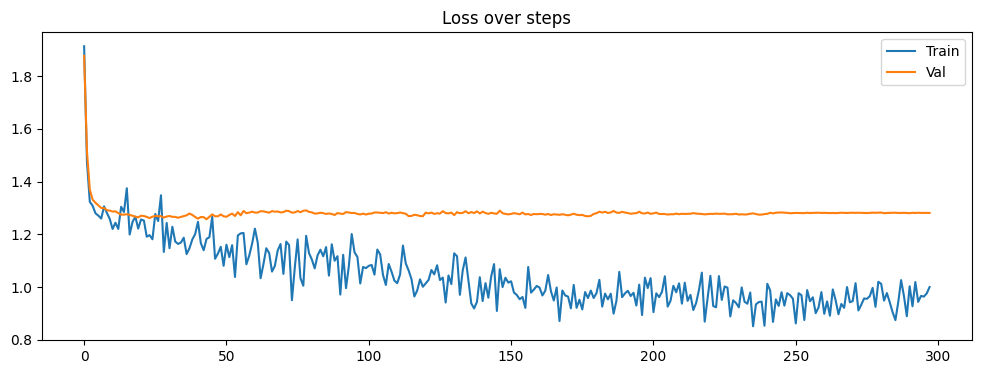

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend()
plt.title('Loss over steps')

Comparing to the example with LoRA, the loss never went as lower as it did with LoRA, which was around 0.5, but in this case the validation loss was much more stable. 

Looking at the test examples, the response also showed the model got some style/alignment post training. The training time took longer, but I believe that is not representative. I am certain my laptop went into 'sleep' mode and the kernel stopped. When I was observing the run, it appeared the training was faster, so I believe this would require less compute than LoRA - which makes sense given this has a lower number of trainable parameters.

In [29]:
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        input_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)
        mask_batch = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_batch,
            attention_mask=mask_batch,
            labels=target_batch
        )

        test_loss += outputs.loss.item()

test_loss /= len(test_loader)
print(f'Test loss: {test_loss:.3f}')

Test loss: 1.263


In [30]:
test_perplexity = calculate_perplexity(test_loss)
print(f'Test Perplexity: {test_perplexity:.2f}')

Test Perplexity: 3.54


The test loss and perplexity are lower with this MiCA implementation than with the LoRA one. Interesting, since training loss was higher, but it seems MiCA might generalize better by just targetting the dimension space using the U matrix as shared in the paper.

In [31]:
bleu_score = calculate_bleu_score(model, test_questions, tokenizer, device, num_samples=20)
print(f'BLEU: {bleu_score:.2f}')

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

BLEU: 0.06


### Conclusion

This notebook explored the used of MiCA as a similar exercise to the ones that were previously available in this project. The goal was to compare how MiCA, the new PEFT technique introduced in April 2026, compared to existing LoRA. Given the paper notes, it seems this technique might be more efficient than LoRA.

From this example, which is limited in form, we can at least validate that even with a lower number of parameters and using the U matrix from SVD, the model is still able to successfully "adapt" to the training goal. Since first introduced, LoRA has been then used for several other training methods that have promoted new training techniques, and even new ideas for inferences by producing LoRA layers on the fly as shared on [SHINE](https://arxiv.org/pdf/2602.06358). It will be interesting to see if MiCA replaces LoRA.

Compared to the original MiCA paper, which only applied the MiCA layers to the q_proj and v_proj, I applied MiCA to all linear layers. In the paper, they state they do this to follow parity with the first implementation of LoRA. Later on, experimentation showed that LoRA could be used, and was beneficial, outside of just the attention layers, so I wanted to test that out.

Below is a quick comparison on how the model was responding before training and after MiCA training:

| Question | Base | MiCA |
|----------|------|------|
| What is the best way to cook fried eggs? | There are several ways to cook fried eggs, and the best method for you will depend on your personal preferences and the tools you have available. Here are a few popular methods:<br><br>1. **Pan-frying**: This is a classic method that involves heating a pan over medium heat, adding a small amount of oil or butter, and then cracking in the eggs. Use a non-stick pan to prevent the eggs from sticking and to make them easier to flip.<br>2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook the eggs. This method allows for more eggs to be cooked at once and can be more efficient.<br>3. **Griddle-frying**: Use a non-stick griddle or cast-iron skillet to cook the eggs. This method is great for cooking multiple eggs at once and can be more efficient than pan-frying.<br>4. **Air fryer-frying**: If you have an air fryer, you can cook fried eggs in it using the air fryer's heat and air circulation. This method is great for cooking eggs with minimal oil and can be healthier than traditional frying.<br>5. **Oven-frying**: You can also cook fried eggs in the oven using a | You want to know the secret to not overcooking those eggs? Alright, here's the deal. You're gonna want to crack 'em into a hot skillet (not too hot, or you'll end up with scrambled... well, you get the idea). Add some oil, let it get nice and hot, then pour in those eggs. Let 'em cook for about 2-3 minutes on each side, or until they're just set. Don't overthink it, just let them cook until they're cooked through. Voilà! |
| How can I recover after a workout? | Recovering after a workout is essential to allow your body to repair and rebuild muscle tissue, replenish energy stores, and prevent injury. Here's a comprehensive guide to help you recover after a workout:<br><br>**Immediate Post-Workout (0-30 minutes)**<br><br>1. **Stretching**: Gentle stretching after a workout can help improve flexibility, reduce muscle soreness, and promote blood flow.<br>2. **Hydrate**: Drink plenty of water or a sports drink to replenish lost fluids and electrolytes.<br>3. **Electrolyte replenishment**: Consume electrolyte-rich foods or supplements, such as bananas (potassium), dates (potassium), or coconut water (electrolytes).<br>4. **Cool down**: Take a 5-10 minute walk or engage in light cardio to help your body cool down.<br><br>**Short-Term Recovery (30 minutes-2 hours)**<br><br>1. **Recovery meal**: Consume a balanced meal or snack with a mix of carbohydrates, protein, and healthy fats to provide energy and support muscle repair.<br>2. **Protein intake**: Aim for 20-30 grams of protein within 30-60 minutes after your workout to help with muscle repair and growth.<br>3. | Recovery's not just about slacking off – it's about getting your body back in top gear. Here's the lowdown: <br><br>1. **Hydrate**: Drink water like it's going out of style. Aim for at least 8 cups (64 oz) within the first 30 minutes post-workout.<br>2. **Electrolytes**: Replenish those lost salts with bananas (potassium), dates (potassium), or sports drinks.<br>3. **Post-workout nutrition**: Consume a balanced meal or snack within 30-60 minutes, including protein, complex carbs, and healthy fats.<br>4. **Stretching**: Get those muscles loose with some gentle stretching – don't bounce, though.<br>5. **Foam rolling**: Use a foam roller to reduce muscle soreness (aka delayed onset muscle soreness – DOMS). |
| Can you help understand how the Roman Empire lost its power? | The Roman Empire's decline and fall can be attributed to a combination of internal and external factors. Here are some key events and reasons that contributed to its decline:<br><br>1. **Overextension and Military Overreach**: The Roman Empire expanded rapidly, stretching its military resources too thin. The empire had to maintain a large army to protect its borders, which led to increased costs, manpower, and logistical challenges.<br>2. **Economic Decline**: The Roman economy experienced a decline in the 2nd century AD, due to factors such as:<br>   - **Inflation**: The Roman currency, the denarius, lost value, making it difficult for the government to pay its debts and maintain public services.<br>   - **Dependence on Slave Labor**: The Roman economy relied heavily on slave labor, which led to social and economic inequalities.<br>   - **Decline of Trade**: The Roman Empire's trade networks declined, reducing its economic growth and stability.<br>3. **Corruption and Mismanagement**: Corruption and mismanagement within the government and administrative structures weakened the empire's institutions and institutions. The Roman Senate, once a powerful and respected institution, became increasingly corrupt and ineffective.<br>4. **External Pressures**: The Roman Empire faced numerous external threats, including | The Roman Empire's downfall - a classic case of "all's fair in love and war" turned into "all's fair in a messy collapse". Seriously though, it was a combination of factors:<br><br>1. **Overextension**: The empire expanded too far, stretching its resources too thin. They tried to control every inch of the known world, which led to inefficiencies and corruption.<br>2. **Economic strain**: The empire's economy was heavily reliant on slave labor, which became increasingly unproductive as the population grew. Additionally, trade disruptions and inflation made it hard to maintain a stable economy.<br>3. **Military fatigue**: The constant wars with neighboring tribes and barbarian hordes took a toll on the legions. They became less effective, and the empire's ability to project power waned.<br>4. **Corruption and mismanagement**: As power grew, so did corruption. The Roman elite became more interested in personal gain than serving the people, leading to a decline in accountability and effectiveness.<br><br>It's like trying to build a machine with too many gears - eventually, it breaks down. The Roman Empire's problems were more systemic than individual mistakes; they just couldn't adapt fast enough to prevent their own downfall. |

While the paper also notes that the the setup they used for not designed for instruction fine-tuning and it was tested for other scenarios, the results still show this techniques works for such cases as well.